<a href="https://colab.research.google.com/github/RosarioH10062002/sced-sart-auditory-stimulation-eeg/blob/main/stimuli/preprocessing_task_stimulus/Preprocessing_Task_Stimulus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LIBRARIES**

In [13]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import os

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**LOAD DATA**

In [14]:
input_folder =  "/content/drive/My Drive/M2_Project_Master/Raw_Images" # Replace this with the path to the "source_images" folder
output_folder = "/content/drive/My Drive/M2_Project_Master/Final_Images" # Replace this with the path to the "processed_images" folder

#**PREPROCESSING PIPELINE**

In [15]:
def rgb_to_gray(imag_rgb):
  b,g,r,a = cv2.split(imag_rgb)
  imag_rgb = cv2.merge([b,g,r])
  gray = cv2.cvtColor(imag_rgb,cv2.COLOR_BGR2GRAY)
  rgb_gray = cv2.merge([gray,gray,gray, a])
  return rgb_gray

def gamma_lin(gray_image):
  gray = gray_image[:, :, 0]   # any of the 0,1,2 channels, all same
  alpha = gray_image[:, :, 3]  # save alpha for later
  gray_f = gray.astype(np.float32) / 255.0
  i_lin = 2 * (gray_f ** (1/2.0)) - 1 # we are gonna get values [-1, +1]
  imag_gamma_lin = i_lin

  return imag_gamma_lin, alpha

def luminance_normal(imag_gamma_lin):
  L = np.mean(imag_gamma_lin)
  i_centered = imag_gamma_lin - L
  imag_lum = i_centered
  return imag_lum

def contrast(img_lum):
  target_std = 0.3
  current_std = np.std(img_lum)
  img_contrast = img_lum * (target_std / current_std)
  return img_contrast

def resize_image(img):
  target_size = (600, 400)   # width, height
  resize_image = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
  return resize_image

name: go_task.png


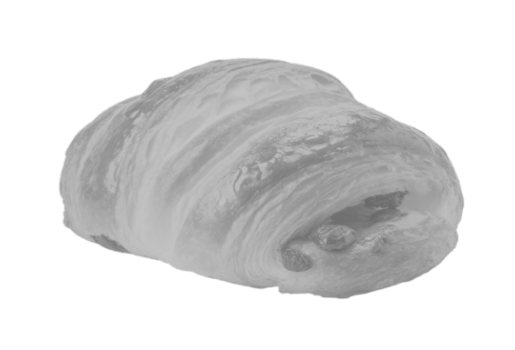

name: nogo_task1.png


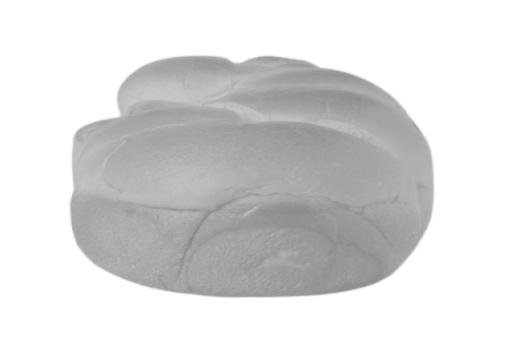

name: nogo_task3.png


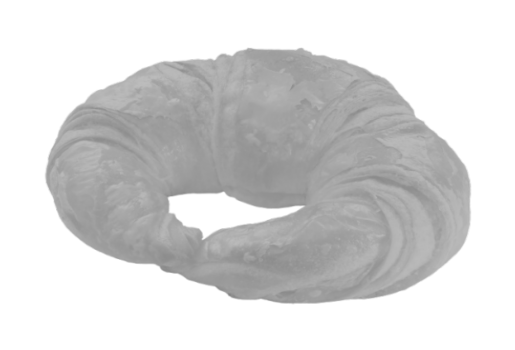

name: nogo_task2.png


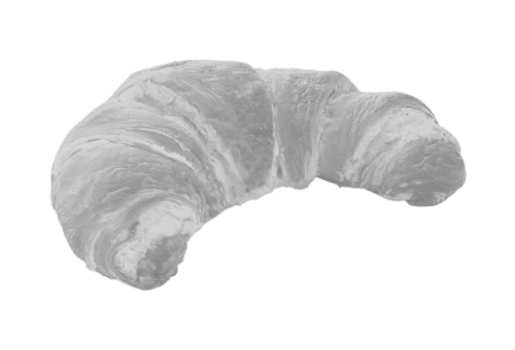

name: nogo_task4.png


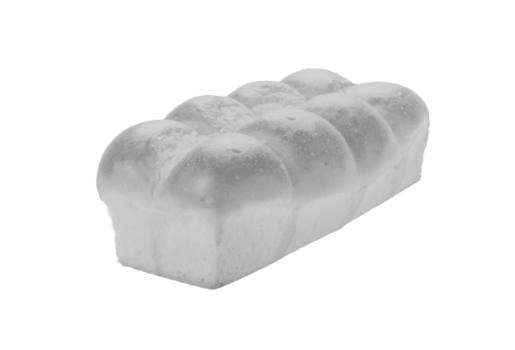

In [16]:
#@title Save the preprocessed image
for f in os.listdir(input_folder):
  if f.endswith((".png")):
    img = cv2.imread(os.path.join(input_folder,f), cv2.IMREAD_UNCHANGED)
    print(f"name: {f}")
    img_rgba = cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
    #plt.imshow(img_rgba)
    #plt.axis("off")
    #plt.show()

    image_resized = resize_image(img)
    gray_image = rgb_to_gray(image_resized)
    gamma_lin_img, alpha = gamma_lin(gray_image)
    img_lum = luminance_normal(gamma_lin_img)
    img_contrast = contrast(img_lum)
    img_01 = (img_contrast + 1)/2 #img_contrast   float32 en [-1, +1]
    img_uint8 = (img_01 * 255).astype(np.uint8)
    final_image = cv2.merge([img_uint8,img_uint8,img_uint8,alpha])
    plt.imshow(final_image)
    plt.axis("off")
    plt.show()
    cv2.imwrite(os.path.join(output_folder,f"white_{f}"), final_image)